<a href="https://colab.research.google.com/github/Shashwat-Mishra15/Brain-Lesion-Segmentation-/blob/main/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import nibabel as nib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define the model save path in Google Drive
MODEL_SAVE_DIR = '/content/drive/MyDrive/Content /BRAINMRI_MODELS'
MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'trained_unet_model.keras')

# Create directory if it doesn't exist
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
print(f"Model will be saved to: {MODEL_PATH}")

Mounted at /content/drive
Model will be saved to: /content/drive/MyDrive/Content /BRAINMRI_MODELS/trained_unet_model.keras


# 1. DATA PREPROCESSING AND LOADING

In [ ]:
class BrainMRIDataLoader:
    """Load and preprocess brain MRI data from MSSEG dataset"""

    def __init__(self, data_dir, target_shape=(128, 128, 128)):
        self.data_dir = data_dir
        self.target_shape = target_shape

    def load_nifti(self, filepath):
        """Load NIfTI file and return numpy array"""
        try:
            img = nib.load(filepath)
            data = img.get_fdata()
            return data
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return None

    def normalize_volume(self, volume):
        """Normalize volume with percentile clipping and z-score normalization"""
        volume = volume.astype(np.float32)

        # Remove outliers using percentile clipping
        p1, p99 = np.percentile(volume[volume > 0], [1, 99])
        volume = np.clip(volume, p1, p99)

        # Z-score normalization
        mean = np.mean(volume[volume > 0])
        std = np.std(volume[volume > 0])
        if std > 0:
            volume = (volume - mean) / std

        # Scale to [0, 1]
        min_val = np.min(volume)
        max_val = np.max(volume)
        if max_val - min_val > 0:
            volume = (volume - min_val) / (max_val - min_val)

        return volume

    def resize_volume(self, volume, target_shape, order=1):
        """Resize 3D volume to target shape"""
        factors = [t / s for t, s in zip(target_shape, volume.shape)]
        return zoom(volume, factors, order=order)

    def load_patient_data(self, patient_folder):
        """Load all modalities for a single patient"""
        patient_id = os.path.basename(patient_folder)
        base_name = patient_id.split('-')[1] if '-' in patient_id else '1'

        # Define file patterns
        modalities = {
            'flair': f'{base_name}-Flair.nii',
            't1': f'{base_name}-T1.nii',
            't2': f'{base_name}-T2.nii',
            'lesion_seg': f'{base_name}-LesionSeg-Flair.nii'
        }

        data = {}
        for key, filename in modalities.items():
            filepath = os.path.join(patient_folder, filename)
            if os.path.exists(filepath):
              volume = self.load_nifti(filepath)
              if volume is not None:
                if key == 'lesion_seg':
                  volume = (volume >0).astype(np.float32)
                  volume = self.resize_volume(volume, self.target_shape, order=0)
                else:
                  volume = self.normalize_volume(volume)
                  volume = self.resize_volume(volume, self.target_shape, order=1)
                data[key] = volume

        return data if len(data) > 0 else None

    def load_dataset(self):
        """Load entire dataset"""
        X_flair, X_t1, X_t2, y = [], [], [], []

        # Iterate through all patient folders
        for patient_folder in sorted(os.listdir(self.data_dir)):
            patient_path = os.path.join(self.data_dir, patient_folder)
            if os.path.isdir(patient_path):
                print(f"Loading {patient_folder}...")
                patient_data = self.load_patient_data(patient_path)

                if patient_data and 'flair' in patient_data and 'lesion_seg' in patient_data:
                    X_flair.append(patient_data['flair'])
                    X_t1.append(patient_data.get('t1', np.zeros(self.target_shape)))
                    X_t2.append(patient_data.get('t2', np.zeros(self.target_shape)))

                    # Binarize segmentation mask
                    mask = patient_data['lesion_seg']
                    mask = (mask > 0).astype(np.float32)
                    y.append(mask)

        # Convert to numpy arrays with explicit dtype
        X_flair = np.array(X_flair, dtype=np.float32)[..., np.newaxis]
        X_t1 = np.array(X_t1, dtype=np.float32)[..., np.newaxis]
        X_t2 = np.array(X_t2, dtype=np.float32)[..., np.newaxis]
        y = np.array(y, dtype=np.float32)[..., np.newaxis]

        # Concatenate modalities
        X = np.concatenate([X_flair, X_t1, X_t2], axis=-1)

        return X, y

# 2. DATA AUGMENTATION

In [ ]:
def augment_volume(volume, mask):
    """Apply random augmentations to volume and mask"""
    # Random intensity scaling for contrast
    if np.random.random() > 0.5:
        scale = np.random.uniform(0.8, 1.2)
        volume = volume * scale
        volume = np.clip(volume, 0, 1)

    # Random gamma correction
    if np.random.random() > 0.5:
        gamma = np.random.uniform(0.8, 1.2)
        volume = np.power(volume, gamma)

    # Random rotation (90 degrees)
    k = np.random.randint(0, 4)
    volume = np.rot90(volume, k, axes=(0, 1))
    mask = np.rot90(mask, k, axes=(0, 1))

    # Add random noise
    noise = np.random.normal(0, 0.01, volume.shape)
    volume = volume + noise
    volume = np.clip(volume, 0, 1)

    return volume, mask

# 3. MODEL ARCHITECTURE - 3D U-NET WITH ATTENTION

In [ ]:
def conv_block(x, filters, kernel_size=3, activation='relu', batch_norm=False): # changed to false
    """Convolutional block with optional batch normalization"""
    x = layers.Conv3D(filters, kernel_size, padding='same')(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def encoder_block(x, filters):
    """Encoder block with two convolutions and max pooling"""
    conv = conv_block(x, filters)
    conv = conv_block(conv, filters)
    pool = layers.MaxPooling3D(pool_size=(2, 2, 2))(conv)
    return conv, pool

def decoder_block(x, skip, filters):
    """Decoder block with upsampling and skip connections"""
    x = layers.Conv3DTranspose(filters, (2, 2, 2), strides=(2, 2, 2), padding='same')(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    x = conv_block(x, filters)
    return x

def attention_gate(x, g, filters):
    """Attention gate for focusing on relevant features"""
    theta_x = layers.Conv3D(filters, 1, strides=(2, 2, 2), padding='same')(x)
    phi_g = layers.Conv3D(filters, 1, padding='same')(g)

    add = layers.Add()([theta_x, phi_g])
    add = layers.Activation('relu')(add)

    psi = layers.Conv3D(1, 1, padding='same')(add)
    psi = layers.Activation('sigmoid')(psi)
    psi = layers.UpSampling3D(size=(2, 2, 2))(psi)

    return layers.Multiply()([x, psi])

def build_3d_unet(input_shape=(128, 128, 128, 3), num_classes=1, use_attention=True):
    """
    Build 3D U-Net model with optional attention gates
    """
    inputs = layers.Input(shape=input_shape)

    # Encoder path
    conv1, pool1 = encoder_block(inputs, 32)
    conv2, pool2 = encoder_block(pool1, 64)
    conv3, pool3 = encoder_block(pool2, 128)
    conv4, pool4 = encoder_block(pool3, 256)

    # Bottleneck
    bottleneck = conv_block(pool4, 512)
    bottleneck = conv_block(bottleneck, 512)

    # Decoder path with attention
    if use_attention:
        conv4 = attention_gate(conv4, bottleneck, 256)
    dec4 = decoder_block(bottleneck, conv4, 256)

    if use_attention:
        conv3 = attention_gate(conv3, dec4, 128)
    dec3 = decoder_block(dec4, conv3, 128)

    if use_attention:
        conv2 = attention_gate(conv2, dec3, 64)
    dec2 = decoder_block(dec3, conv2, 64)

    if use_attention:
        conv1 = attention_gate(conv1, dec2, 32)
    dec1 = decoder_block(dec2, conv1, 32)

    # Output layer
    outputs = layers.Conv3D(num_classes, 1, activation='sigmoid', padding='same')(dec1)

    model = models.Model(inputs=inputs, outputs=outputs, name='3D_UNet_Attention')
    return model

In [ ]:
build_3d_unet()

<Functional name=3D_UNet_Attention, built=True>

# 4. CUSTOM LOSSES AND METRICS

In [ ]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice coefficient for binary segmentation"""
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """Dice loss for training"""
    return 1 - dice_coefficient(y_true, y_pred)

def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    """Focal loss for handling class imbalance"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reshape(bce, [-1])

    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
    focal = alpha_t * tf.pow(1 - p_t, gamma) * bce

    return tf.reduce_mean(focal)

def combined_loss(y_true, y_pred):
    """Combined focal and dice loss with weighting"""
    focal = focal_loss(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return 0.5 * focal + 0.5 * dice

def iou_metric(y_true, y_pred, threshold=0.5):
    """Intersection over Union metric"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > threshold, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-6)

# 5. TRAINING UTILITIES

In [ ]:
class DataGenerator(keras.utils.Sequence):
    """Custom data generator for training with augmentation"""

    def __init__(self, X, y, batch_size=2, augment=True, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.X))
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.X) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        X_batch = np.empty((self.batch_size, *self.X.shape[1:]))
        y_batch = np.empty((self.batch_size, *self.y.shape[1:]))

        for i, idx in enumerate(indexes):
            x, y = self.X[idx], self.y[idx]
            if self.augment:
                x, y = augment_volume(x, y)
            X_batch[i] = x
            y_batch[i] = y

        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

# 6. INFERENCE ON CUSTOM DATA

In [ ]:
def predict_on_custom_data(model, patient_folder, loader):
    """
    Make prediction on a new patient scan
    """
    print(f"\nPredicting on: {patient_folder}")

    # Load patient data
    patient_data = loader.load_patient_data(patient_folder)

    if patient_data is None or 'flair' not in patient_data:
        print("Error: Could not load patient data")
        return None

    # Prepare input
    X_input = np.stack([
        patient_data.get('flair', np.zeros(loader.target_shape)),
        patient_data.get('t1', np.zeros(loader.target_shape)),
        patient_data.get('t2', np.zeros(loader.target_shape))
    ], axis=-1)[np.newaxis, ...]

    # Predict
    prediction = model.predict(X_input, verbose=0)[0, :, :, :, 0]

    # Visualize
    slice_idx = prediction.shape[2] // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(patient_data['flair'][:, :, slice_idx], cmap='gray')
    axes[0].set_title('FLAIR Input')
    axes[0].axis('off')

    axes[1].imshow(prediction[:, :, slice_idx], cmap='jet')
    axes[1].set_title('Predicted Lesions')
    axes[1].axis('off')

    axes[2].imshow(patient_data['flair'][:, :, slice_idx], cmap='gray')
    axes[2].imshow(prediction[:, :, slice_idx] > 0.5, cmap='jet', alpha=0.5)
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return prediction

# 7. MODEL MANAGEMENT - SAVE AND LOAD
**KEY FEATURE:** Check if model exists, load it if available, otherwise train new model

In [ ]:
def load_or_create_model(model_path, input_shape, force_retrain=False):
    """
    Load existing model or create new one

    Args:
        model_path: Path to saved model
        input_shape: Shape of input data
        force_retrain: If True, ignore existing model and create new one

    Returns:
        model: Loaded or newly created model
        is_pretrained: Boolean indicating if model was loaded
    """
    if os.path.exists(model_path) and not force_retrain:
        print("\n" + "="*80)
        print(" FOUND EXISTING MODEL - Loading from disk...")
        print("="*80)

        try:
            # Load model with custom objects
            model = keras.models.load_model(
                model_path,
                custom_objects={
                    'combined_loss': combined_loss,
                    'dice_coefficient': dice_coefficient,
                    'iou_metric': iou_metric
                }
            )
            print(f" Model loaded successfully from: {model_path}")
            print("\nℹ  You can now make predictions without retraining!")
            print("ℹTo retrain, set force_retrain=True\n")
            return model, True
        except Exception as e:
            print(f"  Error loading model: {e}")
            print("Building new model instead...")
    else:
        if force_retrain:
            print("\n FORCE RETRAIN enabled - Building new model...\n")
        else:
            print("\n No existing model found - Building new model...\n")

    # Build new model
    model = build_3d_unet(input_shape=input_shape, use_attention=True)

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-5),
        loss=combined_loss,
        metrics=[dice_coefficient, iou_metric]
    )

    return model, False

# 8. MAIN TRAINING AND PREDICTION PIPELINE
**Run this cell to either train or load the model**

In [ ]:
import os
import numpy as np
import nibabel as nib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# ================================
# CONFIGURATION
# ================================
DATA_DIR = '/content/drive/MyDrive/Content /MSSEG'  # Update this path
TARGET_SHAPE = (64, 64, 64)  # Increased for better detail
BATCH_SIZE = 1
EPOCHS = 100
FORCE_RETRAIN = False  # Set to True to retrain with new TARGET_SHAPE

print("="*80)
print("BRAIN MRI SEGMENTATION - SMART MODEL MANAGEMENT")
print("="*80)

# ================================
# STEP 1: Try to load existing model
# ================================
input_shape = (*TARGET_SHAPE, 3)
model, is_pretrained = load_or_create_model(MODEL_PATH, input_shape, FORCE_RETRAIN)

# ================================
# STEP 2: If model needs training
# ================================
if not is_pretrained:
    print("\n[1/5] Loading and preprocessing data...")
    loader = BrainMRIDataLoader(DATA_DIR, TARGET_SHAPE)
    X, y = loader.load_dataset()
    print(f"Dataset shape: X={X.shape}, y={y.shape}")

    print("\n[2/5] Splitting data...")
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

    print("\n[3/5] Creating data generators...")
    train_gen = DataGenerator(X_train, y_train, batch_size=BATCH_SIZE, augment=True)
    val_gen = DataGenerator(X_val, y_val, batch_size=BATCH_SIZE, augment=False)

    print("\n[4/5] Setting up callbacks...")
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            MODEL_PATH,
            monitor='val_dice_coefficient',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-7
        )
    ]

    print("\n[5/5] Training model...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    print("\n" + "="*80)
    print("TRAINING COMPLETE!")
    print(f"Model saved to: {MODEL_PATH}")
    print(" Next time you run this notebook, the model will load automatically!")
    print("="*80)

print("\n Model is ready for predictions!")

BRAIN MRI SEGMENTATION - SMART MODEL MANAGEMENT

 FOUND EXISTING MODEL - Loading from disk...
 Model loaded successfully from: /content/drive/MyDrive/Content /BRAINMRI_MODELS/trained_unet_model.keras

ℹ  You can now make predictions without retraining!
ℹTo retrain, set force_retrain=True


 Model is ready for predictions!


# 9. MAKE PREDICTIONS ON CUSTOM DATA

MAKING PREDICTION ON CUSTOM DATA

Predicting on: /content/drive/MyDrive/Content /MSSEG/Patient-60


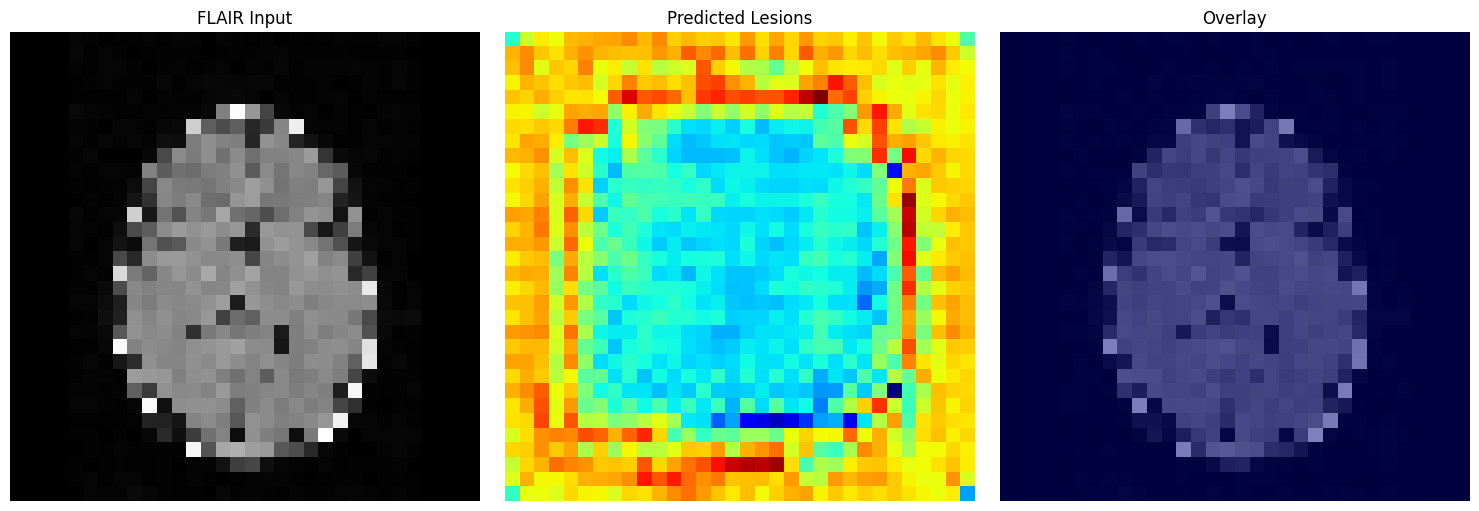


Prediction successful!
Prediction shape: (32, 32, 32)
Lesion pixels detected: 32658
Min: 0.0
Max: 0.9704559
Mean: 0.9311099


In [ ]:
# ================================
# PREDICTION CONFIGURATION
# ================================
PATIENT_FOLDER = '/content/drive/MyDrive/Content /MSSEG/Patient-60'  # Update this path

print("="*80)
print("MAKING PREDICTION ON CUSTOM DATA")
print("="*80)

if 'model' not in locals():
    print("Loading model...")
    model, _ = load_or_create_model(MODEL_PATH, (*(32, 32, 32), 3), force_retrain=False)

_local_TARGET_SHAPE = (32, 32, 32)

loader = BrainMRIDataLoader(DATA_DIR, _local_TARGET_SHAPE)

# Make prediction
if os.path.exists(PATIENT_FOLDER):
    pred_mask = predict_on_custom_data(model, PATIENT_FOLDER, loader)

    if pred_mask is not None:
        print("\nPrediction successful!")
        print(f"Prediction shape: {pred_mask.shape}")
        print(f"Lesion pixels detected: {np.sum(pred_mask > 0.9)}")
else:
    print(f"\nError: Patient folder not found: {PATIENT_FOLDER}")
    print("Please update PATIENT_FOLDER path")

print("Min:", pred_mask.min())
print("Max:", pred_mask.max())
print("Mean:", pred_mask.mean())